# Práctica de Laboratorio 1 
# Parte 1: Análisis Exploratorio de Datos

### Información del Grupo
* **Grupo de Laboratorio:** Viernes a las 08:00h
* **Número de Grupo:** Equipo 1
* **Integrantes:**
  * Lucas Romero Domingo
  * Marco Alcalde Campos
  * Unai Herrero Etxeberria

# Presentación del problema y de los datos

### Elección del conjunto de datos
* **Fuente de los datos:** Conjunto de datos sobre especificaciones de ordenadores portátiles obtenido del repositorio público Kaggle ([Laptop Prices Dataset](https://www.kaggle.com/code/a7med3laa7/laptop-prices/input)).
* **Problema a estudiar:** El mercado de portátiles abarca una gama muy amplia con la consiguiente dispersión de precios. El objetivo de este análisis es determinar cómo influyen las características físicas y de hardware en el coste final y estudiar el posicionamiento de mercado de los distintos fabricantes.

### Variables seleccionadas
Se han seleccionado 6 variables (4 cuantitativas, 2 cualitativas) que combinan especificaciones técnicas con atributos comerciales:

1. **Price** (*Numérica continua*): Precio del portátil en euros. Variable de interés principal.
2. **Company** (Texto): Marca o fabricante (Dell, Lenovo, HP, Apple, Asus, etc.).
3. **TypeName** (Texto): Categoría de diseño del dispositivo (Notebook, Ultrabook, Gaming, 2 in 1 Convertible, Workstation, Netbook).
4. **RAM** (*Numérica discreta*): Capacidad de memoria en GB. Componente crítico para el rendimiento multitarea y el coste.
5. **Weight** (*Numérica continua*): Peso en kg. Permite estudiar el compromiso entre portabilidad y potencia.
6. **Inches** (*Numérica continua*): Diagonal de pantalla en pulgadas. Determina el factor de forma.

### Justificación del conjunto de variables
`RAM` y `Weight` cuantifican el coste directo de la potencia de procesamiento y el esfuerzo de ingeniería. `Company` y `TypeName` capturan el valor de marca y gama de los equipos. `Inches` delimita el tamaño del equipo y condiciona tanto la portabilidad como el tipo de uso previsto.

## Inspección inicial y calidad de los datos

Antes de iniciar el estudio descriptivo, se realiza una auditoría del conjunto de datos para verificar sus dimensiones, la coherencia de los tipos de variables, la presencia de nulos y la existencia de registros duplicados. También se corrigen inconsistencias de formato detectadas en el origen.

In [1]:
import numpy as np
import pandas as pd

# Carga del dataset desde el archivo CSV
df_raw = pd.read_csv("data/laptop_prices.csv", encoding="latin-1")

print(f"Dimensiones completas del repositorio: {df_raw.shape[0]} observaciones y {df_raw.shape[1]} columnas.\n")

# Seleccionamos las variables de interés y las renombramos para facilitar su uso posterior
df = df_raw.copy()
if "Price_euros" in df.columns:
    df = df.rename(columns={"Price_euros": "Price"})
if "Ram" in df.columns:
    df = df.rename(columns={"Ram": "RAM"})

columnas_estudio = ["Company", "TypeName", "Inches", "RAM", "Weight", "Price"]
df_sub = df[columnas_estudio].copy()

# Estructura de las variables seleccionadas
df_sub.info()

# Recuento de valores nulos y porcentaje de valores nulos por variable
valores_nulos = df_sub.isnull().sum()
porcentaje_nulos = (valores_nulos / len(df_sub)) * 100
df_calidad = pd.DataFrame({"Valores Ausentes": valores_nulos, "Porcentaje (%)": porcentaje_nulos})
print(df_calidad)

# Detección de filas duplicadas
num_duplicados = df_sub.duplicated().sum()
print(f"\nNúmero de filas duplicadas en las 6 variables: {num_duplicados} ({(num_duplicados / len(df_sub)) * 100:.2f}%)")

# Comprobación de aspecto final del dataset
df_sub.head()

Dimensiones completas del repositorio: 1275 observaciones y 23 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Company   1275 non-null   str    
 1   TypeName  1275 non-null   str    
 2   Inches    1275 non-null   float64
 3   RAM       1275 non-null   int64  
 4   Weight    1275 non-null   float64
 5   Price     1275 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 59.9 KB
          Valores Ausentes  Porcentaje (%)
Company                  0             0.0
TypeName                 0             0.0
Inches                   0             0.0
RAM                      0             0.0
Weight                   0             0.0
Price                    0             0.0

Número de filas duplicadas en las 6 variables: 15 (1.18%)


,Company,TypeName,Inches,RAM,Weight,Price
0,Apple,Ultrabook,13.3,8,1.37,1339.69
1,Apple,Ultrabook,13.3,8,1.34,898.94
2,HP,Notebook,15.6,8,1.86,575.00
3,Apple,Ultrabook,15.4,16,1.83,2537.45
4,Apple,Ultrabook,13.3,8,1.37,1803.60


### Diagnóstico de la calidad de los datos

* **Tamaño del dataset:** **1 275 observaciones** y **6 variables**.
* **Tipos de datos:** `Company` y `TypeName` como `str`; `RAM` como `int64`; `Inches`, `Weight` y `Price` como `float64`.
* **Nulos:** **0 %** en todas las columnas. El análisis univariante y bivariante puede realizarse sobre el 100 % de la muestra sin imputación.
* **Duplicados:** **15 filas repetidas** (1,18 % de la muestra). En el sector de los ordenadores comerciales es habitual que distintos distribuidores oferten la misma configuración de serie. Al tratarse de un rasgo del mercado y no de un error de toma de datos, hemos optado por **conservar** estos registros para no subestimar la representación real de los modelos más comunes.

## Análisis Univariante

Antes de buscar relaciones entre variables, estudiamos cada una por separado: si un segmento domina el catálogo o una variable tiene una cola larga, los estadísticos globales reflejarán sobre todo ese comportamiento. En las variables numéricas (`Price`, `RAM`, `Weight`, `Inches`) nos interesa qué indican la media, la mediana y los valores extremos sobre la asimetría y los distintos perfiles de producto, en las categóricas (`Company`, `TypeName`), qué categorías predominan y cuáles tienen una representación demasiado escasa. El resultado será un perfil del portátil «típico» del conjunto de datos.

### Price

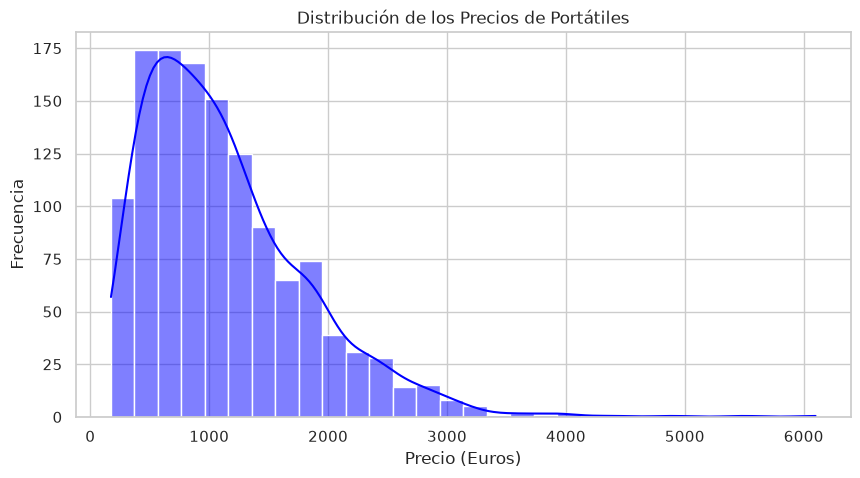

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de los gráficos
sns.set_theme(style="whitegrid")

# Gráfico de la distribución de precios
plt.figure(figsize=(10, 5))
sns.histplot(df_sub['Price'], bins=30, kde=True, color='blue')
plt.title('Distribución de los Precios de Portátiles')
plt.xlabel('Precio (Euros)')
plt.ylabel('Frecuencia')
plt.show()

In [3]:
# ── Estadísticos descriptivos de Price ──────────────────────────────────────
stats_price = df_sub['Price'].describe(percentiles=[.25, .50, .75])
skew_price  = df_sub['Price'].skew()
print('Estadísticos descriptivos de Price (€):')
print(stats_price.to_string())
print(f'\nAsimetría (skewness): {skew_price:.4f}')
print(f'Diferencia media−mediana: '
      f'{df_sub["Price"].mean() - df_sub["Price"].median():.2f} €')

Estadísticos descriptivos de Price (€):
count    1275.000000
mean     1134.969059
std       700.752504
min       174.000000
25%       609.000000
50%       989.000000
75%      1496.500000
max      6099.000000

Asimetría (skewness): 1.5111
Diferencia media−mediana: 145.97 €


**Análisis de la variable `Price`**

La media supera a la mediana: una minoría de equipos de precio muy elevado arrastra el promedio hacia arriba. La skewness positiva lo confirma cuantitativamente. La moda se sitúa en el rango **500–1000 €**, lo que señala que el grueso del catálogo corresponde a equipos de gama media orientados al consumidor general.

La cola derecha se extiende más allá de los 3000 € y alcanza máximos cercanos a los **6000 €**. Estos valores extremos responden a equipos bien definidos —estaciones de trabajo profesionales y portátiles gaming de alto rendimiento— cuyos componentes internos encarecen el producto de forma muy pronunciada.

### Company

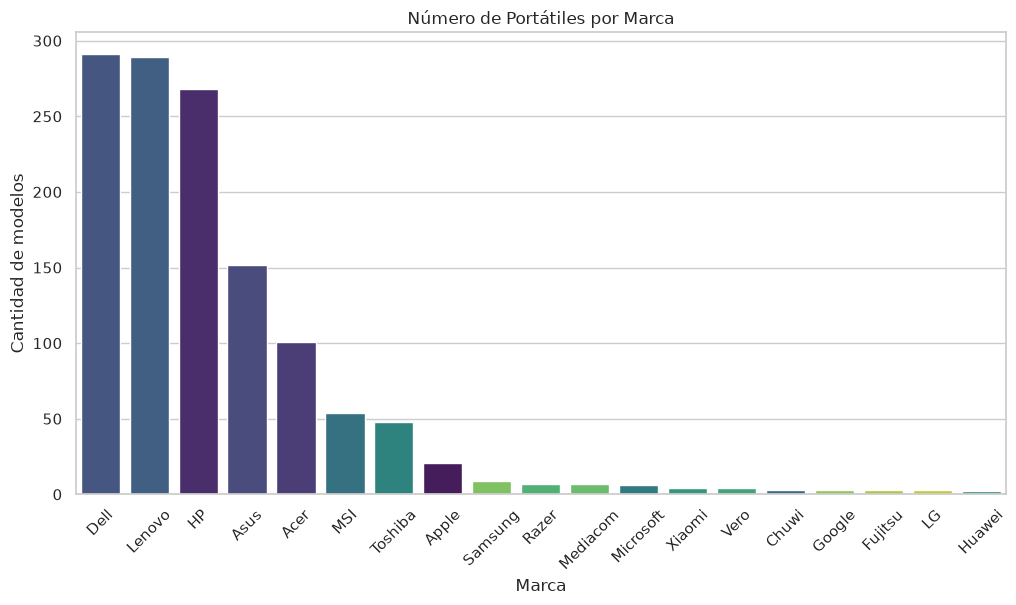

In [4]:
plt.figure(figsize=(12, 6))
orden_marcas = df_sub['Company'].value_counts().index

sns.countplot(data=df_sub, x='Company', order=orden_marcas, hue='Company', palette='viridis', legend=False)

plt.title('Número de Portátiles por Marca')
plt.xlabel('Marca')
plt.ylabel('Cantidad de modelos')
plt.xticks(rotation=45) 
plt.show()

In [5]:
# ── Frecuencias absolutas y relativas de Company ────────────────────────────
freq_company     = df_sub['Company'].value_counts()
freq_company_rel = df_sub['Company'].value_counts(normalize=True).mul(100).round(2)

df_freq_company = pd.DataFrame({
    'Frecuencia absoluta': freq_company,
    'Frecuencia relativa (%)': freq_company_rel
})
print('Tabla de frecuencias de Company (ordenada por frecuencia):')
print(df_freq_company.to_string())

Tabla de frecuencias de Company (ordenada por frecuencia):
           Frecuencia absoluta  Frecuencia relativa (%)
Company                                                
Dell                       291                    22.82
Lenovo                     289                    22.67
HP                         268                    21.02
Asus                       152                    11.92
Acer                       101                     7.92
MSI                         54                     4.24
Toshiba                     48                     3.76
Apple                       21                     1.65
Samsung                      9                     0.71
Razer                        7                     0.55
Mediacom                     7                     0.55
Microsoft                    6                     0.47
Xiaomi                       4                     0.31
Vero                         4                     0.31
Chuwi                        3               

**Análisis de la variable `Company`**

**Dell, Lenovo y HP** concentran en torno a 300 modelos cada una y acumulan más del 65 % del catálogo. A un segundo nivel aparecen Asus y Acer. Podríamos deducir que estas empresas multiplican las configuraciones sobre los mismos chasis para cubrir todos los segmentos de precio.

**Apple** y **Microsoft** tienen cada una menos del 5 % del total. No es ausencia de mercado: su estrategia es mantener un catálogo pequeño y cerrado, orientado a gamas de precios más elevados. En el extremo opuesto, marcas como Vero, Mediacom o Chuwi tienen pocos registros.

### TypeName

                    Frecuencia absoluta  Frecuencia relativa (%)
TypeName                                                        
Notebook                            707                    55.45
Gaming                              205                    16.08
Ultrabook                           194                    15.22
2 in 1 Convertible                  117                     9.18
Workstation                          29                     2.27
Netbook                              23                     1.80


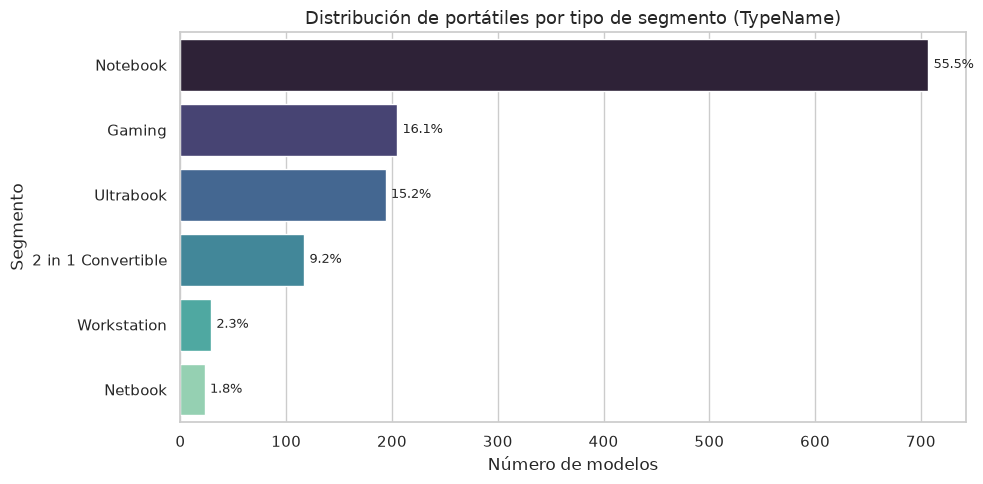

In [6]:
# ── Frecuencias absolutas y relativas de TypeName ───────────────────────────
freq_type = df_sub['TypeName'].value_counts()
freq_rel_type = df_sub['TypeName'].value_counts(normalize=True).mul(100).round(2)

df_freq_type = pd.DataFrame({
    'Frecuencia absoluta': freq_type,
    'Frecuencia relativa (%)': freq_rel_type
})
print(df_freq_type.to_string())

# ── Gráfico de barras horizontal ordenado por frecuencia ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
orden_tipo = freq_type.index

bars = sns.barplot(
    x=freq_type.values,
    y=orden_tipo,
    hue=orden_tipo,
    palette='mako',
    legend=False,
    ax=ax
)

# Anotación del porcentaje al lado de cada barra
for bar, pct in zip(bars.patches, freq_rel_type.values):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontsize=9
    )

ax.set_title('Distribución de portátiles por tipo de segmento (TypeName)', fontsize=13)
ax.set_xlabel('Número de modelos')
ax.set_ylabel('Segmento')
plt.tight_layout()
plt.show()

**Análisis de la variable `TypeName`**

**Notebook** concentra más de la mitad del catálogo: es el formato más fabricado y distribuido, y por tanto el que acumula más variantes comerciales en cualquier plataforma de venta. En el extremo opuesto, **Workstation** y **Netbook** apenas tienen presencia. La primera es minoritaria por naturaleza, ya que se trata de equipos de alto rendimiento y precio elevado con una demanda limitada a nichos profesionales (CAD, renderizado, análisis científico). La segunda corresponde a un formato pequeño y de prestaciones muy básicas, que el mercado ha ido abandonando en favor de los portátiles ligeros y las tablets.

Esta predominancia de Notebook sesga los estadísticos globales de `Price`, `RAM` y `Weight`, y obliga a tener en cuenta las diferencias de tamaño muestral al comparar tipos de portátil en el análisis bivariante.

### RAM

Estadísticos descriptivos de RAM (GB):
count    1275.000000
mean        8.440784
std         5.097809
min         2.000000
25%         4.000000
50%         8.000000
75%         8.000000
90%        16.000000
max        64.000000

Asimetría (skewness): 2.6987
Moda(s):              [8] GB

Distribución de frecuencias por valor de RAM:
     Frecuencia absoluta  Frecuencia relativa (%)
RAM                                              
2                     16                     1.25
4                    367                    28.78
6                     35                     2.75
8                    613                    48.08
12                    25                     1.96
16                   198                    15.53
24                     3                     0.24
32                    17                     1.33
64                     1                     0.08


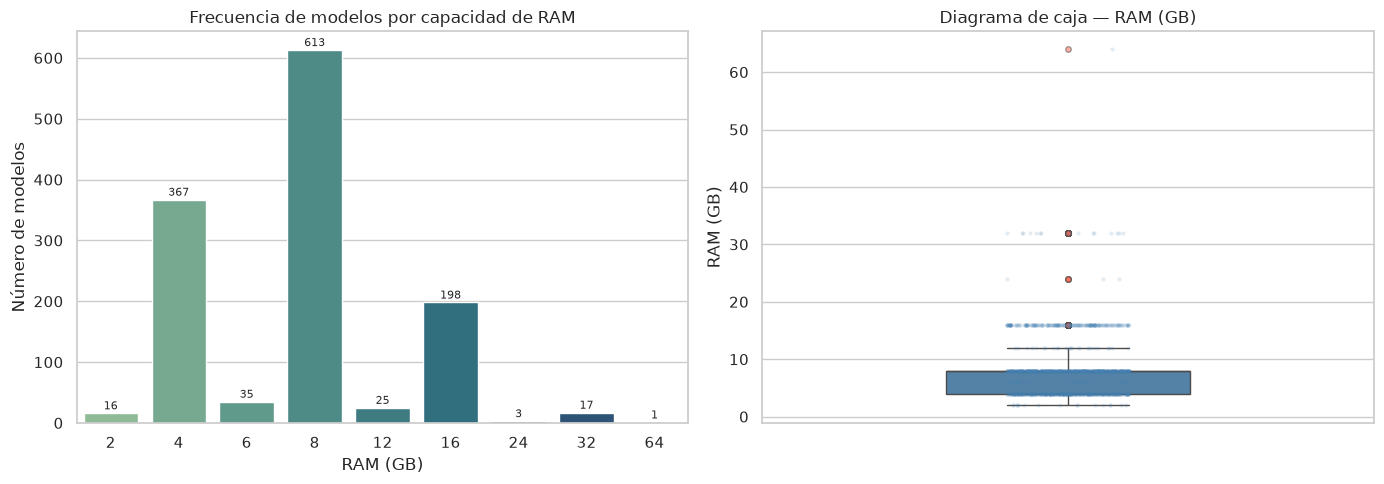

In [7]:
# ── Estadísticos descriptivos de RAM ────────────────────────────────────────
stats_ram = df_sub['RAM'].describe(percentiles=[.25, .50, .75, .90])
skew_ram  = df_sub['RAM'].skew()
print('Estadísticos descriptivos de RAM (GB):')
print(stats_ram.to_string())
print(f'\nAsimetría (skewness): {skew_ram:.4f}')
print(f'Moda(s):              {df_sub["RAM"].mode().tolist()} GB')

# ── Distribución de frecuencias por valor ────────────────────────────────────
freq_ram     = df_sub['RAM'].value_counts().sort_index()
freq_ram_rel = df_sub['RAM'].value_counts(normalize=True).sort_index().mul(100).round(2)
df_freq_ram  = pd.DataFrame({
    'Frecuencia absoluta': freq_ram,
    'Frecuencia relativa (%)': freq_ram_rel
})
print('\nDistribución de frecuencias por valor de RAM:')
print(df_freq_ram.to_string())

# ── Visualización: barras de frecuencia + boxplot ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de frecuencia por valor de RAM
sns.barplot(
    x=freq_ram.index, y=freq_ram.values,
    hue=freq_ram.index.astype(str),
    palette='crest', legend=False, ax=axes[0]
)
axes[0].set_title('Frecuencia de modelos por capacidad de RAM')
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Número de modelos')
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, h + 2,
            f'{int(h)}', ha='center', va='bottom', fontsize=8
        )

# Boxplot con stripplot superpuesto para ver la estructura discreta real
sns.boxplot(y=df_sub['RAM'], color='steelblue', width=0.4, ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='tomato',
                            markersize=4, alpha=0.5))
sns.stripplot(y=df_sub['RAM'], color='steelblue', alpha=0.15,
              jitter=True, size=3, ax=axes[1])
axes[1].set_title('Diagrama de caja — RAM (GB)')
axes[1].set_ylabel('RAM (GB)')

plt.tight_layout()
plt.show()

**Análisis de la variable `RAM`**

La distribución presenta una asimetría positiva marcada (skewness = 2,70): la media queda por encima de la mediana sutilmente y el boxplot muestra una cola larga a la derecha. Moda y mediana coinciden en **8 GB**, que agrupa en torno al 50 % del catálogo y funciona como estándar del mercado de consumo medio en el periodo de referencia. La media sube porque la arrastran los modelos de 16, 32 y 64 GB.

En el boxplot aparecen como atípicos todos los valores por encima de 14 GB, incluido el 16 GB, que no es precisamente raro. Que una parte tan grande de la muestra salga marcada indica que este criterio funciona mal en una variable discreta con pocos valores. No son errores, sino configuraciones de gama alta (gaming, estaciones de trabajo) con un perfil de uso distinto, lo que convierte a `RAM` en un candidato natural para separar segmentos de precio. Lo comprobaremos en el análisis bivariante.

Los valores son siempre múltiplos de 2 GB y se concentran en unos pocos estándar (4, 8 y 16 GB).

### Weight

Estadísticos descriptivos de Weight (kg):
count    1275.000000
mean        2.040525
std         0.669196
min         0.690000
10%         1.255200
25%         1.500000
50%         2.040000
75%         2.310000
90%         2.800000
max         4.700000

Asimetría (skewness): 1.1508
Curtosis  (kurtosis): 2.4284


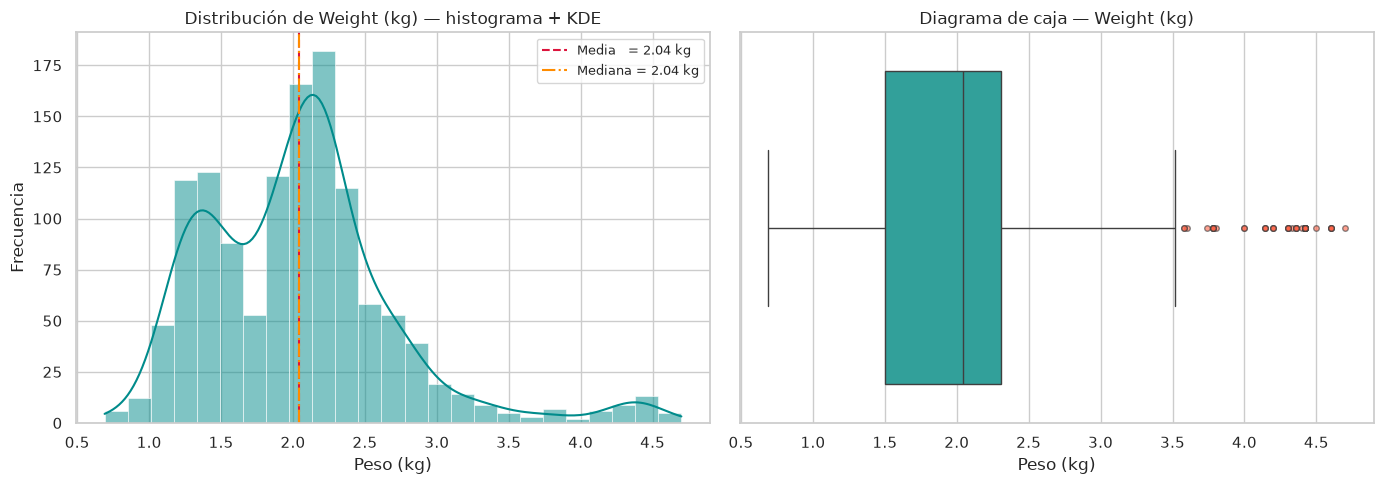

In [8]:
# ── Estadísticos descriptivos de Weight ─────────────────────────────────────
stats_weight = df_sub['Weight'].describe(percentiles=[.10, .25, .50, .75, .90])
skew_weight  = df_sub['Weight'].skew()
kurt_weight  = df_sub['Weight'].kurt()
print('Estadísticos descriptivos de Weight (kg):')
print(stats_weight.to_string())
print(f'\nAsimetría (skewness): {skew_weight:.4f}')
print(f'Curtosis  (kurtosis): {kurt_weight:.4f}')

# ── Visualización: histograma/KDE + boxplot horizontal ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE y líneas de media/mediana
sns.histplot(df_sub['Weight'], bins=25, kde=True, color='darkcyan',
             edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].axvline(df_sub['Weight'].mean(), color='crimson', linestyle='--',
                linewidth=1.5,
                label=f"Media   = {df_sub['Weight'].mean():.2f} kg")
axes[0].axvline(df_sub['Weight'].median(), color='darkorange', linestyle='-.',
                linewidth=1.5,
                label=f"Mediana = {df_sub['Weight'].median():.2f} kg")
axes[0].set_title('Distribución de Weight (kg) — histograma + KDE')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Boxplot horizontal
sns.boxplot(x=df_sub['Weight'], color='lightseagreen', ax=axes[1],
            flierprops=dict(marker='o', markerfacecolor='tomato',
                            markersize=4, alpha=0.6))
axes[1].set_title('Diagrama de caja — Weight (kg)')
axes[1].set_xlabel('Peso (kg)')

plt.tight_layout()
plt.show()

**Análisis de la variable `Weight`**

La distribución es unimodal y presenta una asimetría positiva marcada. Aun así, media y mediana prácticamente coinciden (en torno a 2 kg): la cola derecha es larga, pero reúne tan pocos equipos que no llega a desplazar la tendencia central.

El grueso de la distribución se concentra entre **1,5 y 2,3 kg**, franja que cubre la oferta estándar de portátiles de 15 pulgadas para uso general y profesional. Reducir el peso por debajo del kilogramo exige un esfuerzo de ingeniería que eleva el coste de fabricación significativamente, lo que empuja a los fabricantes a concentrar la oferta en el rango medio-alto, donde el equilibrio entre portabilidad y precio es más favorable para el volumen de ventas. La cola izquierda —por debajo del kilogramo— corresponde a los ultrabooks de alta gama (12–13 pulgadas), de precio unitario elevado pero escasa frecuencia. Por encima de 3 kg aparecen los portátiles gaming y de reemplazo de sobremesa, con sistemas de refrigeración voluminosos.

Los valores extremos (<1 kg o >4 kg) son productos reales cuya demanda escapa a la tendencia central.

### Inches

Estadísticos descriptivos de Inches (pulgadas):
count    1275.000000
mean       15.022902
std         1.429470
min        10.100000
10%        13.300000
25%        14.000000
50%        15.600000
75%        15.600000
90%        17.300000
max        18.400000

Asimetría (skewness): -0.4386
Curtosis  (kurtosis): -0.0840

Distribución de frecuencias por tamaño de pantalla:
        Frecuencia absoluta  Frecuencia relativa (%)
Inches                                              
10.1                      4                     0.31
11.3                      1                     0.08
11.6                     31                     2.43
12.0                      6                     0.47
12.3                      5                     0.39
12.5                     39                     3.06
13.0                      2                     0.16
13.3                    160                    12.55
13.5                      6                     0.47
13.9                      6                  

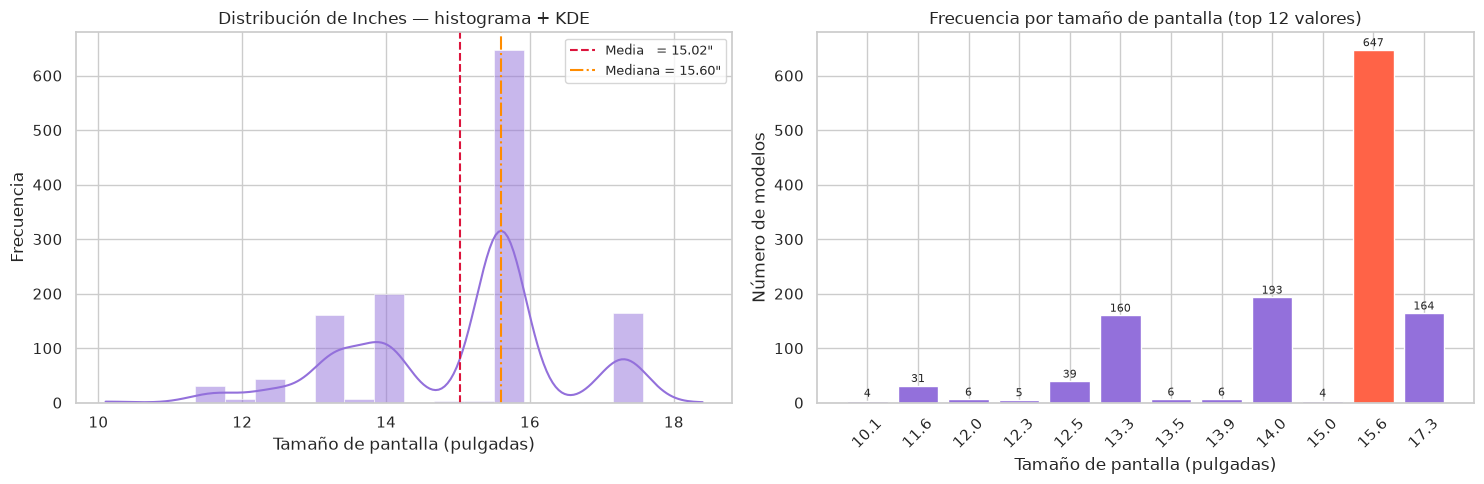

In [9]:
# ── Estadísticos descriptivos de Inches ─────────────────────────────────────
stats_inches = df_sub['Inches'].describe(percentiles=[.10, .25, .50, .75, .90])
skew_inches  = df_sub['Inches'].skew()
kurt_inches  = df_sub['Inches'].kurt()
print('Estadísticos descriptivos de Inches (pulgadas):')
print(stats_inches.to_string())
print(f'\nAsimetría (skewness): {skew_inches:.4f}')
print(f'Curtosis  (kurtosis): {kurt_inches:.4f}')

# ── Distribución de frecuencias por tamaño exacto ────────────────────────────
freq_inches     = df_sub['Inches'].value_counts().sort_index()
freq_inches_rel = df_sub['Inches'].value_counts(normalize=True).sort_index().mul(100).round(2)
df_freq_inches  = pd.DataFrame({
    'Frecuencia absoluta': freq_inches,
    'Frecuencia relativa (%)': freq_inches_rel
})
print('\nDistribución de frecuencias por tamaño de pantalla:')
print(df_freq_inches.to_string())

# ── Visualización: histograma/KDE + barras por valor exacto ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma con KDE y líneas de media/mediana
sns.histplot(df_sub['Inches'], bins=20, kde=True, color='mediumpurple',
             edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].axvline(df_sub['Inches'].mean(), color='crimson', linestyle='--',
                linewidth=1.5,
                label=f'Media   = {df_sub["Inches"].mean():.2f}"')
axes[0].axvline(df_sub['Inches'].median(), color='darkorange', linestyle='-.',
                linewidth=1.5,
                label=f'Mediana = {df_sub["Inches"].median():.2f}"')
axes[0].set_title('Distribución de Inches — histograma + KDE')
axes[0].set_xlabel('Tamaño de pantalla (pulgadas)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Barras de frecuencia por valor exacto (top 12 tamaños)
top_sizes  = freq_inches.nlargest(12).sort_index()
max_size   = top_sizes.idxmax()
colors_bar = ['tomato' if v == max_size else 'mediumpurple' for v in top_sizes.index]
axes[1].bar(top_sizes.index.astype(str), top_sizes.values,
            color=colors_bar, edgecolor='white')
axes[1].set_title('Frecuencia por tamaño de pantalla (top 12 valores)')
axes[1].set_xlabel('Tamaño de pantalla (pulgadas)')
axes[1].set_ylabel('Número de modelos')
axes[1].tick_params(axis='x', rotation=45)
for x, count in enumerate(top_sizes.values):
    axes[1].text(x, count + 2, str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Análisis de la variable `Inches`**

La distribución se concentra en pocos tamaños estándar, y **15,6 pulgadas** domina con algo más de la mitad del catálogo (50,8 %). Es el formato que mejor equilibra superficie de pantalla, portabilidad y coste de producción para el consumidor medio. Le siguen 14" (15,1 %), 17,3" (12,9 %) y 13,3" (12,6 %).

La media (15,02") queda por debajo de la mediana (15,6"), y la asimetría es ligeramente negativa (−0,44). Esto se debe a la cola de pantallas pequeñas (11,6", 12,5" o 13,3"), más numerosa que la de pantallas grandes, que solo llega hasta el 17,3" y 18,4". La curtosis (−0,08) es prácticamente la de una normal, así que la forma de la distribución no viene de colas especialmente pesadas, sino de que casi todos los equipos se agrupan en unos pocos valores concretos.

Los tamaños extremos (10,1" y 18,4") tienen muy pocos registros (4 y 1 equipos) y corresponden a productos de nicho, por lo que apenas influyen en el conjunto.

### Conclusión

El perfil típico del catálogo es un **Notebook** de uso general con 8 GB de RAM, pantalla de 15,6 pulgadas y peso en torno a los 2 kg. Sobre ese núcleo se superponen nichos (gaming, workstation, ultrabooks) que generan las asimetrías y valores extremos observados en cada variable.

## Análisis Bivariante

Cada sub-apartado parte de una pregunta concreta sobre el mercado de portátiles y cubre los tres casos requeridos: dos variables numéricas, una numérica con una categórica, y dos variables categóricas.

### 5.1 Dos variables numéricas — `Price` × `RAM`

¿En qué medida la capacidad de RAM determina el precio de un portátil? Se estudia la relación mediante un diagrama de dispersión y se calcula tanto la correlación de **Pearson** —asociación lineal— como la de **Spearman** —monotonía sin asumir linealidad— para determinar qué tipo de relación subyace.

Correlación de Pearson  (RAM, Price):
  r = 0.7403   p-valor = 9.13e-222

Correlación de Spearman (RAM, Price):
  ρ = 0.7642   p-valor = 9.30e-245

Diferencia |ρ − r| = 0.0240


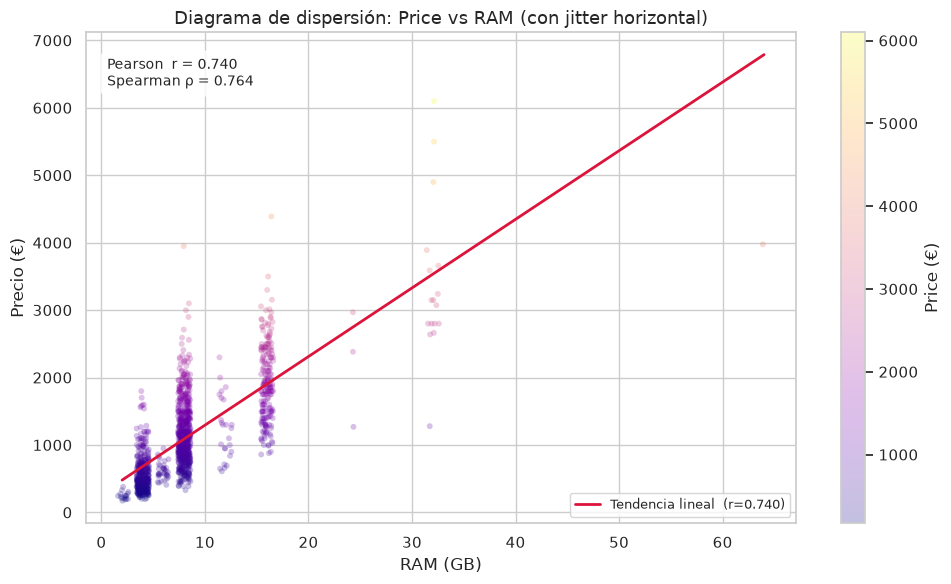

In [10]:
from scipy import stats

# ── Correlaciones de Pearson y Spearman ──────────────────────────────────────
r_pearson,  p_pearson  = stats.pearsonr(df_sub['RAM'], df_sub['Price'])
r_spearman, p_spearman = stats.spearmanr(df_sub['RAM'], df_sub['Price'])

print('Correlación de Pearson  (RAM, Price):')
print(f'  r = {r_pearson:.4f}   p-valor = {p_pearson:.2e}')
print()
print('Correlación de Spearman (RAM, Price):')
print(f'  ρ = {r_spearman:.4f}   p-valor = {p_spearman:.2e}')
print()
print(f'Diferencia |ρ − r| = {abs(r_spearman - r_pearson):.4f}')

# ── Diagrama de dispersión con jitter horizontal (RAM es discreta) ────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Jitter leve en el eje X para evitar solapamiento total de puntos
rng = np.random.default_rng(42)
ram_jitter = df_sub['RAM'] + rng.uniform(-0.6, 0.6, size=len(df_sub))

scatter = ax.scatter(
    ram_jitter, df_sub['Price'],
    alpha=0.25, s=18, c=df_sub['Price'],
    cmap='plasma', edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Price (€)')

# Línea de tendencia (regresión lineal simple) para visualizar la pendiente
m, b, *_ = stats.linregress(df_sub['RAM'], df_sub['Price'])
x_line = np.linspace(df_sub['RAM'].min(), df_sub['RAM'].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        label=f'Tendencia lineal  (r={r_pearson:.3f})')

# Anotación de coeficientes
ax.text(0.03, 0.95,
        f'Pearson  r = {r_pearson:.3f}\nSpearman ρ = {r_spearman:.3f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax.set_title('Diagrama de dispersión: Price vs RAM (con jitter horizontal)', fontsize=13)
ax.set_xlabel('RAM (GB)')
ax.set_ylabel('Precio (€)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# ── Resumen interpretativo con valores numéricos embebidos ──────────────────
print('─' * 60)
print('RESUMEN COMPARATIVO DE CORRELACIONES — Price vs RAM')
print('─' * 60)
print(f'  Pearson  r  = {r_pearson:.4f}   → asociación lineal')
print(f'  Spearman ρ  = {r_spearman:.4f}   → asociación monotónica')
print(f'  Diferencia  = {abs(r_spearman - r_pearson):.4f}   '
      f'({"Spearman > Pearson → relación más monotónica que lineal" if r_spearman > r_pearson else "Pearson >= Spearman"})')
print()
print(f'  Rango intercuartílico de Price en equipos con 8 GB RAM:')
q1_8 = df_sub.loc[df_sub['RAM'] == 8, 'Price'].quantile(0.25)
q3_8 = df_sub.loc[df_sub['RAM'] == 8, 'Price'].quantile(0.75)
print(f'    Q1 = {q1_8:.0f} €   Q3 = {q3_8:.0f} €   IQR = {q3_8 - q1_8:.0f} €')
print('  → Alta dispersión dentro del mismo nivel de RAM.')

────────────────────────────────────────────────────────────
RESUMEN COMPARATIVO DE CORRELACIONES — Price vs RAM
────────────────────────────────────────────────────────────
  Pearson  r  = 0.7403   → asociación lineal
  Spearman ρ  = 0.7642   → asociación monotónica
  Diferencia  = 0.0240   (Spearman > Pearson → relación más monotónica que lineal)

  Rango intercuartílico de Price en equipos con 8 GB RAM:
    Q1 = 847 €   Q3 = 1450 €   IQR = 603 €
  → Alta dispersión dentro del mismo nivel de RAM.


**Análisis e Interpretación**

Ambos coeficientes son positivos y estadísticamente significativos (p-valores prácticamente nulos): a mayor RAM, mayor precio. Sin embargo, la diferencia entre ellos revela matices importantes.

**Pearson r** cuantifica la asociación lineal. El valor obtenido es moderado-alto, pero la dispersión dentro de cada nivel de RAM es considerable —el IQR de Price para equipos de 8 GB supera los 400 €—, lo que indica que la RAM no es el único factor determinante del precio.

**Spearman ρ supera a Pearson r**: la relación es más monotónica que lineal. Los saltos de precio al pasar de 4 → 8 → 16 → 32 GB no son proporcionales. El salto de 32 a 64 GB implica un sobrecoste desproporcionado porque en ese rango se encarecen simultáneamente la GPU dedicada, el almacenamiento NVMe y otros componentes del equipo.

El gráfico de dispersión muestra una **forma escalonada** propia de variables discretas: nubes de puntos agrupadas en columnas verticales sobre cada valor de RAM. La amplitud vertical de cada columna mide cuánto varía el precio dentro del mismo nivel de RAM —reflejo del peso de factores como la marca, el procesador o la pantalla—.

Apple o Microsoft comercializan equipos de 8 GB por encima de los 1 000 €, mientras que marcas de volumen venden portátiles de 16 GB por debajo de esa cifra. La RAM elevada es con frecuencia un **síntoma de gama alta** más que su causa directa; la correlación observada no establece por sí sola una relación causal entre ambas variables.

### 5.2 Variable numérica × variable categórica — `Price` por `TypeName`

¿Cuánto difiere el precio según el segmento de uso del portátil? Se analizan las medias, la dispersión, el solapamiento entre distribuciones y la presencia de valores extremos en cada grupo.

Estadísticos de Price (€) por TypeName:
                      n    media  mediana     std      q25     q75  minimo  maximo
TypeName                                                                          
Workstation          29  2280.36   2064.9  712.64  1855.00  2445.0  1369.0  4389.0
Ultrabook           194  1556.68   1499.0  484.74  1159.78  1869.0   499.0  3100.0
Gaming              205  1731.38   1492.8  814.17  1169.00  2199.0   699.0  6099.0
2 in 1 Convertible  117  1289.71   1199.0  617.44   798.01  1799.0   275.0  2824.0
Notebook            707   788.74    695.0  446.82   478.94   982.5   196.0  4899.0
Netbook              23   673.38    355.0  592.09   269.00  1066.5   174.0  1908.0


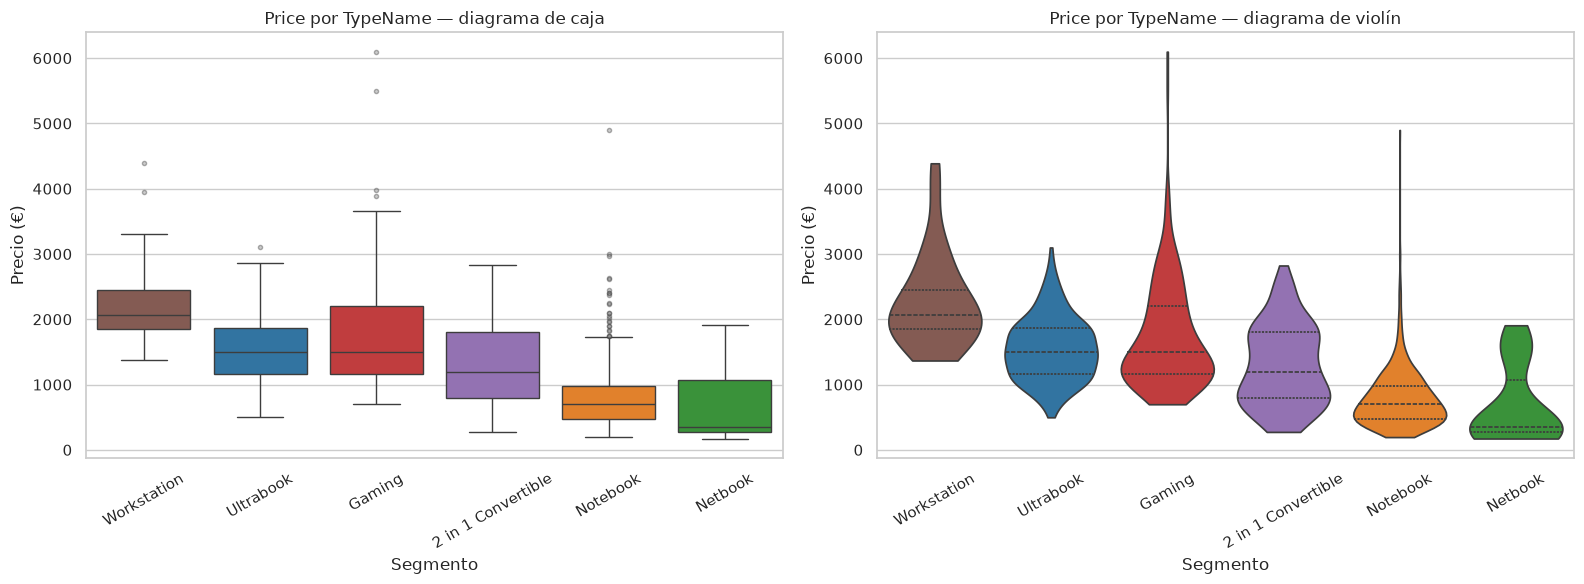

In [12]:
# ── Estadísticos descriptivos de Price por TypeName ─────────────────────────
stats_by_type = (
    df_sub.groupby('TypeName')['Price']
    .agg(
        n='count',
        media='mean',
        mediana='median',
        std='std',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        minimo='min',
        maximo='max'
    )
    .sort_values('mediana', ascending=False)
    .round(2)
)
print('Estadísticos de Price (€) por TypeName:')
print(stats_by_type.to_string())

# Orden de categorías por mediana descendente (para los gráficos)
orden_tipo_precio = stats_by_type.index.tolist()

# ── Visualización: boxplot + violín superpuestos ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot con franja de mediana visible
sns.boxplot(
    data=df_sub, x='TypeName', y='Price',
    order=orden_tipo_precio,
    hue='TypeName', palette='tab10', legend=False,
    flierprops=dict(marker='o', markerfacecolor='grey',
                    markersize=3, alpha=0.4),
    ax=axes[0]
)
axes[0].set_title('Price por TypeName — diagrama de caja', fontsize=12)
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Precio (€)')
axes[0].tick_params(axis='x', rotation=30)

# Violín para ver la forma completa de la distribución
sns.violinplot(
    data=df_sub, x='TypeName', y='Price',
    order=orden_tipo_precio,
    hue='TypeName', palette='tab10', legend=False,
    inner='quartile', cut=0,
    ax=axes[1]
)
axes[1].set_title('Price por TypeName — diagrama de violín', fontsize=12)
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Precio (€)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Análisis e Interpretación**

**Nivel central (mediana):**  
**Workstation** lidera con diferencia: el sobrecoste de los componentes profesionales (GPU certificada, ECC RAM, materiales de grado industrial) se refleja directamente en la mediana. En el extremo opuesto, **Netbook** tiene la mediana más baja y un violín muy estrecho — el mercado de estos equipos está muy estandarizado en precio.

**Dispersión intra-grupo:**  
El violín de **Gaming** es especialmente ancho en la zona alta: gamas entry-level (GPU media, pantalla 60 Hz) conviviendo con flagships que pueden superar los 3 000 €. La variedad de posicionamientos dentro del segmento explica esa amplitud.

**Solapamiento entre distribuciones:**  
El solapamiento entre **Notebook**, **Ultrabook** y **2 in 1 Convertible** es considerable. El tipo de portátil por sí solo no permite predecir el precio con precisión; la marca, las especificaciones internas y el posicionamiento comercial introducen variabilidad adicional que el tipo no captura.

**Valores extremos:**  
Aparecen outliers superiores en todas las categorías. En **Notebook** son especialmente abundantes: es el segmento más grande y acumula también equipos de nicho que difícilmente encajan en otra categoría. Esto sugiere que `TypeName` es una clasificación declarativa del fabricante, no siempre coherente con el posicionamiento real del producto.

### 5.3 Dos variables categóricas — `TypeName` × `Company`

¿Existen marcas que se especialicen en determinados tipos de portátil, o el catálogo de todas es igualmente diverso? Una concentración en ciertos segmentos revelaría el posicionamiento de mercado de cada fabricante. Para mantener la tabla de contingencia manejable, el análisis se restringe a las **6 marcas con mayor presencia** en el dataset, reduciendo así el número de celdas con frecuencias muy bajas que distorsionarían el test estadístico.

In [13]:
from scipy.stats import chi2_contingency
from statsmodels.graphics.mosaicplot import mosaic

# ── Selección de las 6 marcas con más modelos ─────────────────────────────────
top6_brands = df_sub['Company'].value_counts().nlargest(6).index.tolist()
df_biv = df_sub[df_sub['Company'].isin(top6_brands)].copy()
print(f'Marcas seleccionadas: {top6_brands}')
print(f'Observaciones en el subconjunto: {len(df_biv)} ')
print(f'({len(df_biv)/len(df_sub)*100:.1f} % del dataset original)\n')

# ── Tabla de contingencia (frecuencias absolutas) ─────────────────────────────
tabla_cont = pd.crosstab(
    df_biv['TypeName'], df_biv['Company'],
    margins=True, margins_name='TOTAL'
)
print('Tabla de contingencia — frecuencias absolutas:')
print(tabla_cont.to_string())

# ── Frecuencias condicionadas: distribución de TypeName DENTRO de cada marca ──
tabla_cond = pd.crosstab(
    df_biv['TypeName'], df_biv['Company'],
    normalize='columns'
).mul(100).round(1)
print('\nFrecuencias condicionadas (% por columna — distribución de tipo dentro de cada marca):')
print(tabla_cond.to_string())

# ── Test chi-cuadrado de independencia ────────────────────────────────────────
# Usamos la tabla sin márgenes
tabla_sin_margenes = pd.crosstab(df_biv['TypeName'], df_biv['Company'])
chi2, p_chi2, dof, expected = chi2_contingency(tabla_sin_margenes)

print(f'\nTest chi-cuadrado de independencia:')
print(f'  χ² = {chi2:.4f}')
print(f'  Grados de libertad = {dof}')
print(f'  p-valor = {p_chi2:.2e}')

# Verificación del supuesto: frecuencias esperadas >= 5 en al menos el 80 % de celdas
freq_esp = pd.DataFrame(expected, index=tabla_sin_margenes.index,
                        columns=tabla_sin_margenes.columns)
pct_celdas_ok = (freq_esp >= 5).values.mean() * 100
print(f'  Celdas con frecuencia esperada >= 5: {pct_celdas_ok:.1f} % '
      f'(supuesto del test: >= 80 %)')

Marcas seleccionadas: ['Dell', 'Lenovo', 'HP', 'Asus', 'Acer', 'MSI']
Observaciones en el subconjunto: 1155 
(90.6 % del dataset original)

Tabla de contingencia — frecuencias absolutas:
Company             Acer  Asus  Dell   HP  Lenovo  MSI  TOTAL
TypeName                                                     
2 in 1 Convertible     8    13    30   19      44    0    114
Gaming                 8    54    40   12      32   54    200
Netbook                5     4     2    7       4    0     22
Notebook              76    63   159  180     174    0    652
Ultrabook              4    18    49   36      31    0    138
Workstation            0     0    11   14       4    0     29
TOTAL                101   152   291  268     289   54   1155

Frecuencias condicionadas (% por columna — distribución de tipo dentro de cada marca):
Company             Acer  Asus  Dell    HP  Lenovo    MSI
TypeName                                                 
2 in 1 Convertible   7.9   8.6  10.3   7.1    15.2 

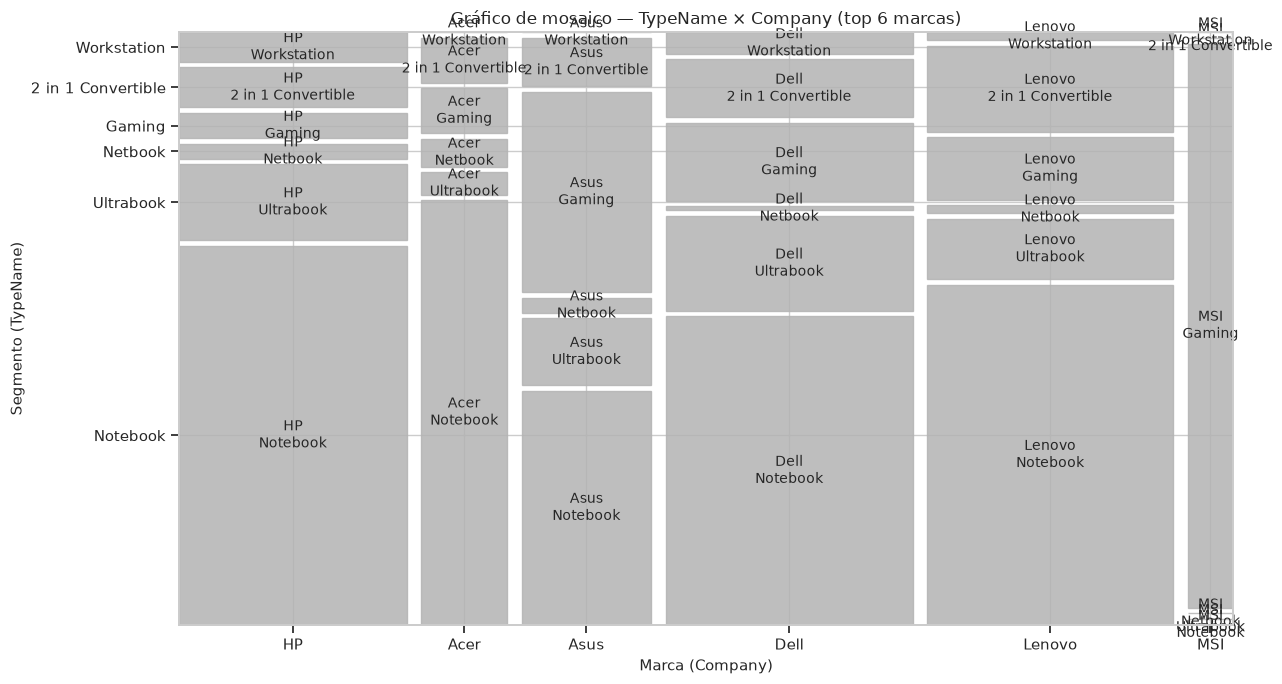

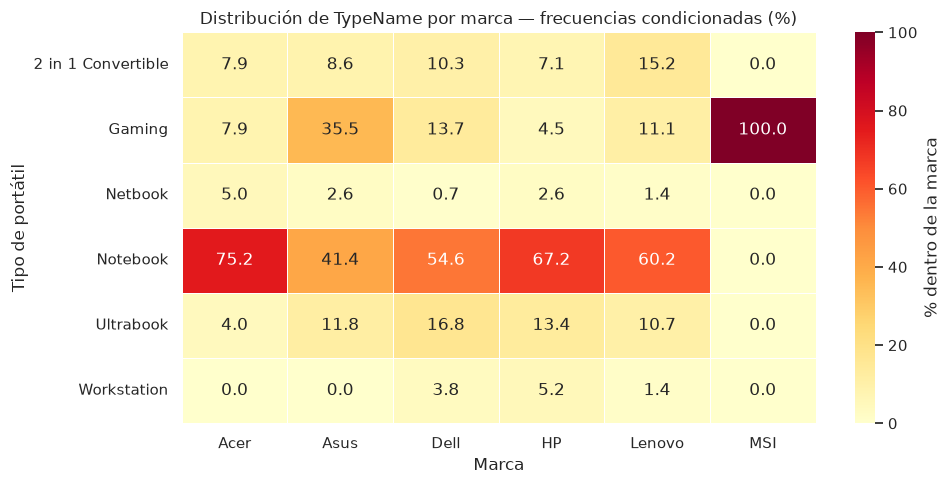

In [14]:
# ── Gráfico de mosaico ────────────────────────────────────────────────────────
# Construimos un diccionario de proporciones para el mosaico
# statsmodels.mosaic acepta un DataFrame en formato largo
fig, ax = plt.subplots(figsize=(13, 7))

# Paleta de colores para los segmentos
tipos = tabla_sin_margenes.index.tolist()
palette_mosaic = dict(zip(tipos, sns.color_palette('tab10', n_colors=len(tipos))))

def color_fn(key):
    tipo = key[0]  # primera dimensión = TypeName
    c = palette_mosaic.get(tipo, (0.7, 0.7, 0.7))
    return {'color': c, 'alpha': 0.85}

mosaic(
    df_biv,
    ['Company', 'TypeName'],
    ax=ax,
    properties=color_fn,
    gap=0.015,
    title='Gráfico de mosaico — TypeName × Company (top 6 marcas)'
)

ax.set_xlabel('Marca (Company)', fontsize=11)
ax.set_ylabel('Segmento (TypeName)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Heatmap de frecuencias condicionadas (alternativa visual a la tabla) ───────
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    tabla_cond,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% dentro de la marca'},
    ax=ax
)
ax.set_title('Distribución de TypeName por marca — frecuencias condicionadas (%)',
             fontsize=12)
ax.set_xlabel('Marca')
ax.set_ylabel('Tipo de portátil')
plt.tight_layout()
plt.show()

**Análisis e Interpretación**

**Hipótesis del test chi-cuadrado:**

- **H₀:** La distribución de tipos de portátil (`TypeName`) es independiente de la marca (`Company`); todas las marcas tienen proporciones de segmento equivalentes.
- **H₁:** Existe asociación entre `Company` y `TypeName`; algunas marcas se especializan en ciertos segmentos.

El p-valor obtenido es << 0,05, por lo que **se rechaza H₀**. La distribución de segmentos no es homogénea entre marcas.

La tabla de frecuencias condicionadas y el heatmap muestran dónde están las diferencias:

- **Apple** concentra casi toda su oferta en **Notebook** y prácticamente no tiene presencia en Gaming ni Workstation. Es coherente con un catálogo cerrado de MacBooks orientados al usuario profesional de uso general.
- **MSI** —y en menor medida **Asus**— tiene una proporción de portátiles **Gaming** notablemente superior a la media del dataset; sus líneas específicas (MSI Gaming, ASUS ROG/TUF) dominan ese nicho.
- **Dell**, **Lenovo** y **HP** muestran distribuciones equilibradas: ofrecen modelos en todos los segmentos (ofimática, professional, convertibles, gaming).

Dos cautelas: primero, con más de 1 200 observaciones el chi-cuadrado tiene potencia estadística suficiente para rechazar H₀ incluso ante diferencias de magnitud modesta; los resultados deben interpretarse considerando ese margen. Segundo, el supuesto de frecuencias esperadas ≥ 5 se cumple, por lo que el test es formalmente válido. Conocer la marca reduce —pero no elimina— la incertidumbre sobre el segmento de un portátil.

## Conclusiones finales

### Ideas principales

**1. El mercado es estructuralmente bimodal.**  
La distribución de `Price` y la de `RAM` apuntan a la misma fractura: un segmento dominante de uso general (portátiles de 8 GB, 500–1 000 €) y un segmento de nicho —gaming, workstation, ultrabooks premium— que genera las colas largas observadas en ambas variables. Cualquier estadístico global debe interpretarse con esa dualidad en mente.

**2. La RAM es el predictor numérico más asociado al precio, pero la relación no es lineal.**  
Spearman supera a Pearson: los saltos de precio entre niveles de RAM son crecientes pero no proporcionales. De 4 a 8 GB el incremento es moderado; de 16 a 32 GB o más aparece un sobrecoste desproporcionado porque en esos niveles el hardware circundante (GPU, almacenamiento, refrigeración) también escala. La RAM funciona como **indicador de gama**, no como causa directa del precio.

**3. `TypeName` diferencia niveles de precio, pero el solapamiento limita su valor predictivo.**  
Workstation y Netbook ocupan los extremos con distribuciones estrechas y bien separadas. Notebook, Ultrabook y 2-in-1 Convertible presentan rangos que se superponen ampliamente: el posicionamiento de precio depende de la combinación de marca, especificaciones y segmento, y no puede inferirse de ninguna de estas dimensiones por separado.

**4. Las marcas tienen especializaciones de segmento estadísticamente verificables.**  
El test chi-cuadrado rechaza la independencia entre `Company` y `TypeName` con evidencia muy fuerte. Apple se concentra casi exclusivamente en Notebook; MSI orienta la mayor parte de su catálogo al gaming; Dell, Lenovo y HP mantienen carteras diversificadas.

**5. El formato de 15,6 pulgadas y ~2 kg es el estándar del mercado masivo.**  
Más del 40 % del catálogo converge en ese tamaño de pantalla, y el rango 1,5–2,5 kg concentra la inmensa mayoría de los modelos. Fuera de ese estándar, los fabricantes operan en nichos con menor presión de precio pero también con menor escala de producción.

### Limitaciones del análisis

**Alcance temporal.**  
El dataset es una instantánea estática del mercado. La irrupción de procesadores ARM de bajo consumo, el estándar DDR5 o los paneles OLED han modificado las relaciones precio-especificación desde que se recopilaron los datos, por lo que las correlaciones y distribuciones observadas pueden no ser representativas del mercado actual.

**Variables no disponibles.**  
El análisis cubre solo seis variables. El modelo de procesador (CPU), el tipo de GPU, la capacidad y tecnología del almacenamiento (HDD vs. SSD NVMe) y la resolución de pantalla son determinantes clave del precio que no se han podido incorporar. Su ausencia impide explicar, por ejemplo, por qué dos portátiles con la misma RAM tienen precios radicalmente distintos.

**Escasa representación muestral en algunas categorías.**  
Netbook y Workstation tienen muy pocos registros frente a Notebook. Los estadísticos calculados para esas categorías —mediana, IQR, etc.— llevan intervalos de confianza amplios; los outliers observados en Workstation podrían desaparecer o reforzarse con una muestra más grande de ese segmento.

**Sesgo de plataforma.**  
El dataset procede de una única fuente de comercio electrónico. Algunos fabricantes o segmentos pueden estar sobre o infrarrepresentados respecto a su cuota real de mercado. Los precios recogidos son precios de catálogo en el momento de la extracción; no reflejan descuentos, promociones ni precios de segunda mano.